In [1]:
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [2]:
df = pd.read_csv("disease.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
  Patient_ID,Age,Gender,Symptoms,Blood_Pressure,Sugar_Level,Cholesterol,Medical_History,Disease
0                1,45,Male,Fever,120,90,180,None,Flu                                           
1  2,60,Female,Chest Pain,150,140,240,Diabetes,He...                                           
2               3,25,Male,Cough,110,85,170,None,Cold                                           
3  4,50,Female,Headache,130,100,200,Hypertension,...                                           
4                5,35,Male,Fever,125,95,190,None,Flu                                           

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 1 columns):
 #   Column                                                                                         Non-Null Count  Dtype 
---  ------                                                                                         --------------  ----- 
 0   Patient_ID,Age,Gender,Symptoms,Blood_Press

In [47]:
import pandas as pd

df = pd.read_csv("disease.csv", header=None)

# Split the single column into multiple columns
df = df[0].str.split(",", expand=True)

# Set proper column names
df.columns = [
    'Patient_ID',
    'Age',
    'Gender',
    'Symptoms',
    'Blood_Pressure',
    'Sugar_Level',
    'Cholesterol',
    'Medical_History',
    'Disease'
]

print(df.head())

  Patient_ID Age  Gender    Symptoms Blood_Pressure Sugar_Level Cholesterol  \
0          1  45    Male       Fever            120          90         180   
1          2  60  Female  Chest Pain            150         140         240   
2          3  25    Male       Cough            110          85         170   
3          4  50  Female    Headache            130         100         200   
4          5  35    Male       Fever            125          95         190   

  Medical_History        Disease  
0            None            Flu  
1        Diabetes  Heart Disease  
2            None           Cold  
3    Hypertension       Migraine  
4            None            Flu  


In [48]:
from sklearn.impute import SimpleImputer

num_cols = ['Age', 'Blood_Pressure', 'Sugar_Level', 'Cholesterol']

imputer_num = SimpleImputer(strategy='mean')

df[num_cols] = imputer_num.fit_transform(df[num_cols])

cat_cols = ['Gender', 'Symptoms', 'Medical_History']

imputer_cat = SimpleImputer(strategy='most_frequent')

df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

print(df.head())

  Patient_ID   Age  Gender    Symptoms  Blood_Pressure  Sugar_Level  \
0          1  45.0    Male       Fever           120.0         90.0   
1          2  60.0  Female  Chest Pain           150.0        140.0   
2          3  25.0    Male       Cough           110.0         85.0   
3          4  50.0  Female    Headache           130.0        100.0   
4          5  35.0    Male       Fever           125.0         95.0   

   Cholesterol Medical_History        Disease  
0        180.0            None            Flu  
1        240.0        Diabetes  Heart Disease  
2        170.0            None           Cold  
3        200.0    Hypertension       Migraine  
4        190.0            None            Flu  


In [49]:
encoder = LabelEncoder()
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])
df['Disease'] = encoder.fit_transform(df['Disease'])

In [45]:
X = df.drop(['Patient_ID', 'Disease'], axis=1)
y = df['Disease']

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())



Features:
    Age  Gender  Symptoms  Blood_Pressure  Sugar_Level  Cholesterol  \
0  45.0       1         2           120.0         90.0        180.0   
1  60.0       0         0           150.0        140.0        240.0   
2  25.0       1         1           110.0         85.0        170.0   
3  50.0       0         3           130.0        100.0        200.0   
4  35.0       1         2           125.0         95.0        190.0   

   Medical_History  
0                3  
1                0  
2                3  
3                2  
4                3  

Target:
0    1
1    2
2    0
3    3
4    1
Name: Disease, dtype: int64


In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)


[[-0.09027623  1.040833    0.43643578 -0.76519981 -0.76095026 -0.79280134
   0.80295507]
 [ 0.90541752 -0.96076892 -1.38204664  0.96863661  1.24155042  1.00086685
  -2.0647416 ]
 [-1.41786791  1.040833   -0.47280543 -1.34314528 -0.96120033 -1.09174604
   0.80295507]
 [ 0.24162168 -0.96076892  1.34567699 -0.18725433 -0.36045012 -0.19491194
  -0.15294382]
 [-0.75407207  1.040833    0.43643578 -0.47622707 -0.56070019 -0.49385664
   0.80295507]
 [ 1.56921336 -0.96076892 -1.38204664  1.54658209  1.64205056  1.59875625
  -1.10884271]
 [-1.21872915 -0.96076892 -0.47280543 -1.05417254 -0.84105029 -0.94227369
   0.80295507]
 [ 0.5735196   1.040833    1.34567699  0.67966388  0.44055015  0.40297745
  -0.15294382]
 [-0.42217415 -0.96076892  0.43643578 -0.64961071 -0.68085023 -0.64332899
   0.80295507]
 [ 1.23731544  1.040833   -1.38204664  1.25760935  1.44180049  1.29981155
  -2.0647416 ]
 [-1.08596999  1.040833   -0.47280543 -0.8807889  -0.92115031 -1.0319571
   0.80295507]
 [ 0.10886252 -0.96076

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (20, 7)
Testing Data Shape: (5, 7)


In [33]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

accuracy_results = {}

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results[name] = accuracy

    print("\n===================================")
    print("Model:", name)
    print("Accuracy:", accuracy)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)


Model: Logistic Regression
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Confusion Matrix:
[[3 0]
 [0 2]]

Model: Decision Tree
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Confusion Matrix:
[[3 0]
 [0 2]]

Model: Random Forest
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00    

In [34]:
best_model_name = max(accuracy_results, key=accuracy_results.get)

print("\n===================================")
print("Best Model:", best_model_name)
print("Best Accuracy:", accuracy_results[best_model_name])


Best Model: Logistic Regression
Best Accuracy: 1.0


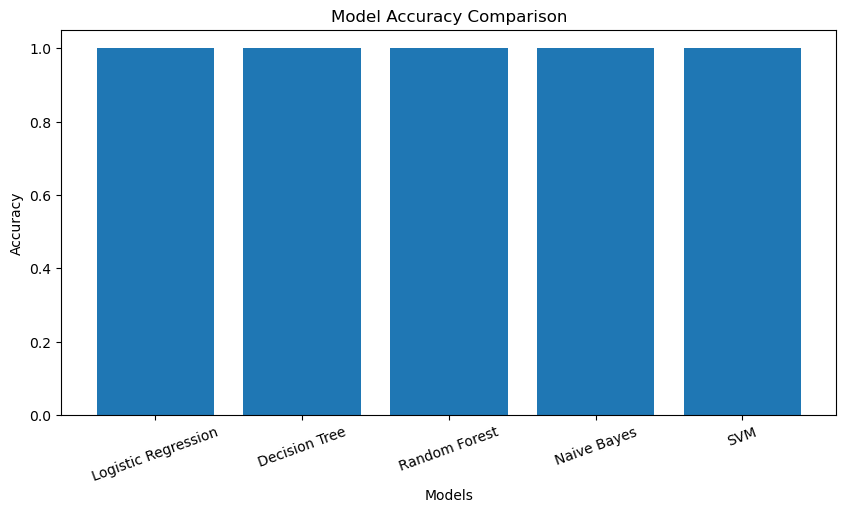

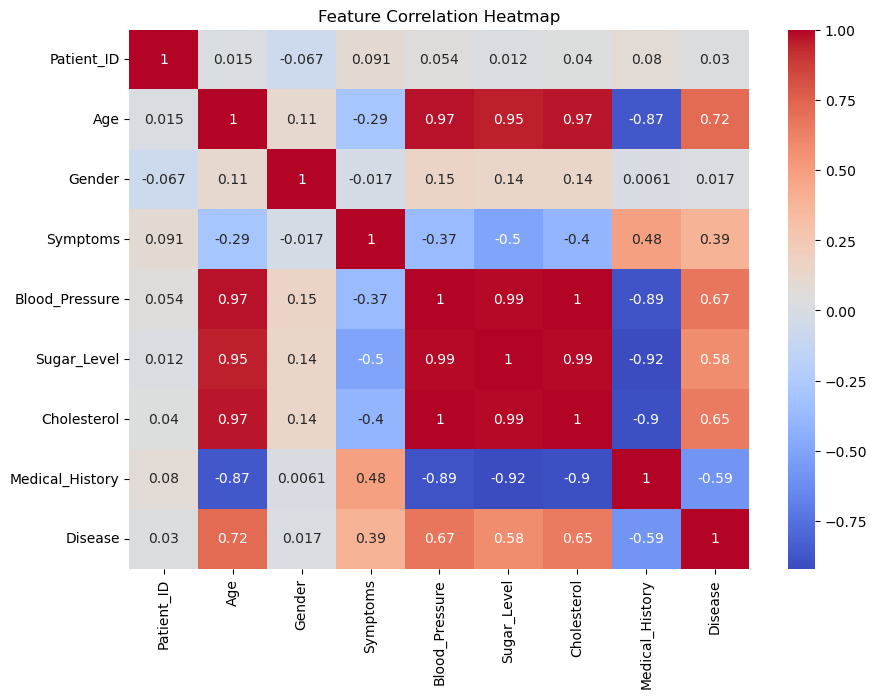

In [35]:
# Accuracy Comparison Graph
plt.figure(figsize=(10, 5))

plt.bar(
    accuracy_results.keys(),
    accuracy_results.values()
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [36]:
# Use Best Model
best_model = models[best_model_name]

# Example New Patient Data
# Format:
# Age, Gender, Symptoms, Blood_Pressure,
# Sugar_Level, Cholesterol, Medical_History

new_patient = pd.DataFrame({
    'Age': [45],
    'Gender': ['Male'],
    'Symptoms': ['Fever'],
    'Blood_Pressure': [130],
    'Sugar_Level': [110],
    'Cholesterol': [200],
    'Medical_History': ['Diabetes']
})

# Encode Categorical Columns

new_patient['Gender'] = encoder.fit_transform(
    new_patient['Gender']
)

new_patient['Symptoms'] = encoder.fit_transform(
    new_patient['Symptoms']
)

new_patient['Medical_History'] = encoder.fit_transform(
    new_patient['Medical_History']
)

# Scale Data
new_patient_scaled = scaler.transform(new_patient)

# Predict Disease
prediction = best_model.predict(new_patient_scaled)

print("\n===================================")
print("Predicted Disease Code:", prediction[0])


Predicted Disease Code: 2


In [37]:
import joblib

joblib.dump(best_model, "disease_prediction_model.pkl")

print("\nModel Saved Successfully!")

# ============================================
# END OF PROJECT
# ============================================


Model Saved Successfully!
